In [1]:
import torch
import pickle
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
#from tabpfn import TabPFNClassifier  
from functools import partial
#import tabpfn.encoders as encoders
#from tabpfn.scripts.transformer_prediction_interface import transformer_predict, get_params_from_config, load_model_workflow_my
from sklearn.metrics import (  
    accuracy_score,  
    precision_score,  
    recall_score,  
    f1_score,  
    roc_auc_score,  
    precision_recall_curve,  
    auc,  
    confusion_matrix  
)  
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from imblearn.over_sampling import SMOTE
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn  # 确保引入 nn 模块
import torch.optim as optim  # 确保引入 optim 模块
from sklearn.preprocessing import StandardScaler 
import seaborn as sns
from matplotlib.colors import ListedColormap 

In [2]:
from sklearn.cluster import DBSCAN  
from sklearn.neighbors import NearestNeighbors  
from sklearn.utils import resample 
from sklearn.decomposition import PCA 
from sklearn.cluster import KMeans 
from sklearn.manifold import TSNE 
import umap
from imblearn.under_sampling import EditedNearestNeighbours 
from sklearn.metrics import pairwise_distances 
from sklearn.cluster import MeanShift 
import hdbscan
from collections import Counter 
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score
from imblearn.under_sampling import EditedNearestNeighbours
from scipy.stats import wasserstein_distance
from imblearn.under_sampling import CondensedNearestNeighbour  

In [3]:
from matplotlib import font_manager as fm 
from matplotlib import rcParams 
# 加载字体  
font_path = "/root/autodl-fs/Sq-TabPFN/tabpfn/NotoSansSC-Regular.ttf"
fm.fontManager.addfont(font_path)  
plt.rcParams['font.family'] = "Noto Sans SC"  
plt.rcParams['legend.fontsize'] = 14  
plt.rcParams['axes.titlesize'] = 16  
plt.rcParams['axes.labelsize'] = 14 

In [4]:
# ========== 统一可视化模板 ==========  
def plot_tsne_distribution(X_embedded, y, title, filename):  
    """通用可视化函数，保持样式一致"""  
    plt.figure(figsize=(10, 6))  # 固定画布尺寸  
    
    # 统一绘图参数  
    plt.scatter(X_embedded[y==0, 0], X_embedded[y==0, 1],  
                color='#1f77b4', edgecolor='white', alpha=0.7,  
                linewidth=0.5, label='非抗衰化合物')  
    plt.scatter(X_embedded[y==1, 0], X_embedded[y==1, 1],  
                color='#ff7f0e', edgecolor='white', alpha=0.8,  
                linewidth=0.5, marker='o', label='抗衰化合物')  

    # 统一格式设置  
    plt.title(title, fontsize=14, pad=12)  
    plt.xlabel('t-SNE Component 1', fontsize=12)  
    plt.ylabel('t-SNE Component 2', fontsize=12)  
    plt.legend(loc='upper right', frameon=True,   
              edgecolor='#444444', fontsize=14)  
    plt.grid(False)  
    
    # 统一保存参数  
    plt.savefig(filename, dpi=300, bbox_inches='tight')  
    plt.show()

训练集中各标签分布：
0    635
1    165
Name: count, dtype: int64


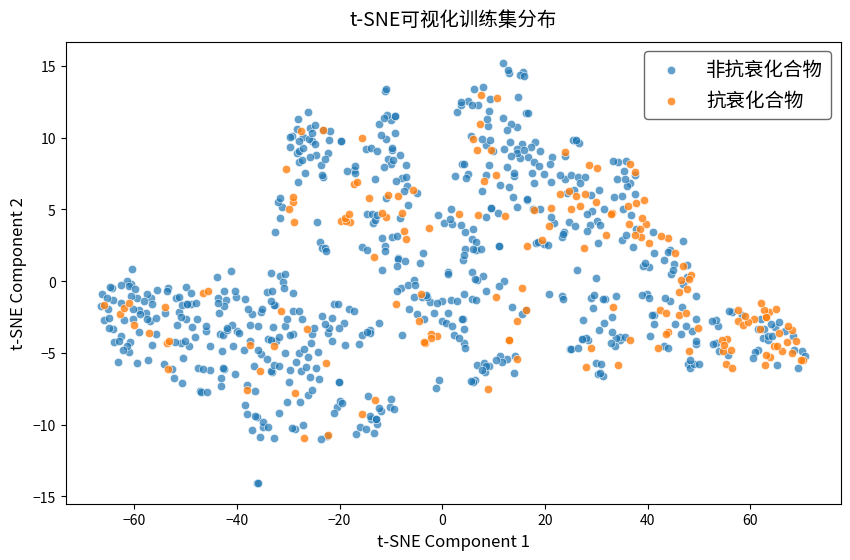

In [5]:
# ========== 数据准备 ==========    
# 原始数据读取  
data = pd.read_csv("支持集——30个特征+抗衰概率.csv")  # 假设第一列是化合物名称  

# 数据准备  
X = data.iloc[:, 3:].values  # 化合物特征  
y = data.iloc[:, 1].values    # 标签  

# 分层划分训练集和测试集  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)  

# 统计训练集中数据分布  
distribution = pd.Series(y_train).value_counts()  
print("训练集中各标签分布：")  
print(distribution)  

# 使用t-SNE可视化原始训练分布  
tsne = TSNE(n_components=2, random_state=42)  
X_embedded = tsne.fit_transform(X_train)  

# 调用统一可视化函数（关键修改点）  
plot_tsne_distribution(  
    X_embedded=X_embedded,  
    y=y_train,  
    title='t-SNE可视化训练集分布',  
    filename="tsne_visualization_v2.png"  
)  

修正后验证：
- 去噪样本数: 514
- 概率值数量: 514

去噪后训练集分布：
0    349
1    165
Name: count, dtype: int64


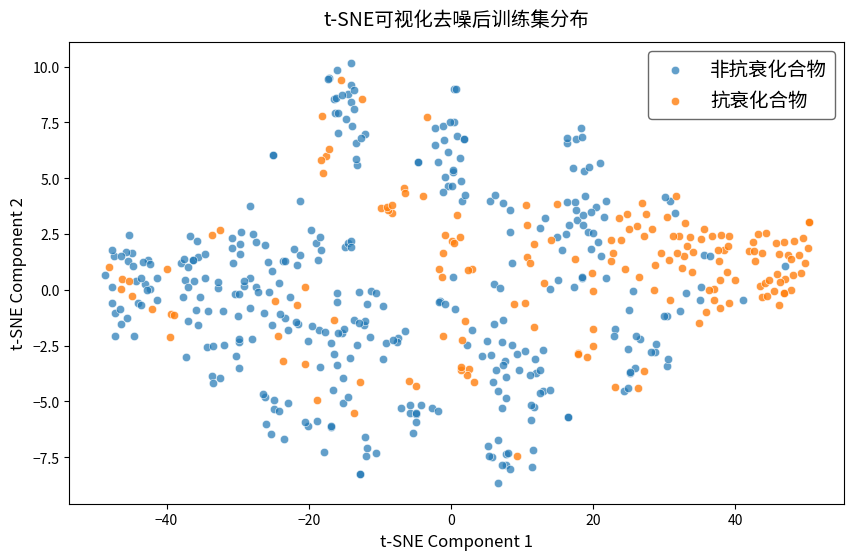

In [6]:
# ========== 兼容性修正方案 ==========  
from imblearn.under_sampling import EditedNearestNeighbours  
import numpy as np  
 
# 执行ENN去噪  
enn = EditedNearestNeighbours(n_neighbors=5, kind_sel='all')  
X_train_enn, y_train_enn = enn.fit_resample(X_train, y_train)  

# ========== 改进的索引追踪方案 ==========  
from collections import defaultdict  

# 创建增强型哈希字典（处理重复样本）  
def create_enhanced_hash(X):  
    hash_dict = defaultdict(list)  
    for idx, x in enumerate(X):  
        hash_key = hash(x.tobytes())  
        hash_dict[hash_key].append(idx)  
    return hash_dict  

# 创建原始训练集的哈希字典  
enhanced_train_hash = create_enhanced_hash(X_train)  

# 获取所有去噪样本的原始索引（关键修正）  
full_kept_indices = []  
for x in X_train_enn:  
    candidates = enhanced_train_hash.get(hash(x.tobytes()), [])  
    if candidates:  
        # 选择时间最近的索引（假设数据按时间顺序排列）  
        full_kept_indices.append(candidates[-1])  
    else:  
        # 找不到时的备用方案：最近邻匹配  
        distances = np.linalg.norm(X_train - x, axis=1)  
        full_kept_indices.append(np.argmin(distances))  

# 获取完整概率序列  
train_probs = data.iloc[full_kept_indices, 2].values  

# 维度验证  
assert len(train_probs) == len(X_train_enn), \
    f"维度不匹配: probs({len(train_probs)}) vs X_train_enn({len(X_train_enn)})"  

print(f"修正后验证：\n"  
      f"- 去噪样本数: {len(X_train_enn)}\n"  
      f"- 概率值数量: {len(train_probs)}")  


# 统计去噪后分布  
distribution_enn = pd.Series(y_train_enn).value_counts()  
print("\n去噪后训练集分布：")  
print(distribution_enn)  

# ========== 去噪后可视化 ==========  
# 重新计算t-SNE嵌入（保持参数一致）  
tsne = TSNE(n_components=2, random_state=42, perplexity=30)  # 显式声明参数  
X_embedded_enn = tsne.fit_transform(X_train_enn)  

# 调用统一可视化函数（关键修改点）  
plot_tsne_distribution(  
    X_embedded=X_embedded_enn,  
    y=y_train_enn,  
    title='t-SNE可视化去噪后训练集分布',  
    filename="tsne_denoised_distribution.png"  
)  

初始安全样本数：45
开始计算Wasserstein距离...
有效根样本数：27

过采样后分布：
0.0    349
1.0    349
Name: count, dtype: int64


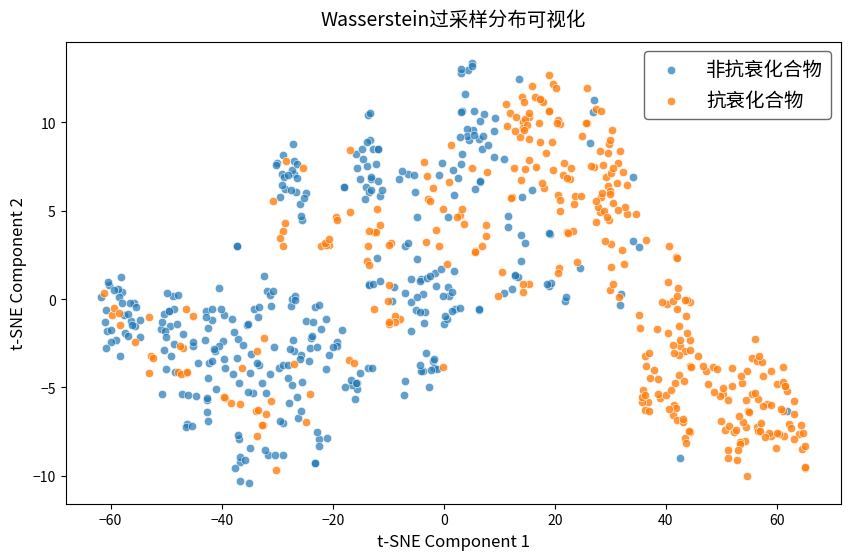

In [8]:
# ========== 过采样核心实现 ==========  
from scipy.stats import wasserstein_distance  
from sklearn.neighbors import NearestNeighbors  
import numpy as np  

# 参数配置  
k2 = 5       # 最近邻数量  
alpha = 0.6  # 安全系数权重  
beta = 0.4   # 距离权重  

# a) 筛选安全样本  
safe_mask = (train_probs >= 0.5) & (y_train_enn == 1)  
safe_samples = X_train_enn[safe_mask]  
safe_labels = y_train_enn[safe_mask]  
print(f"初始安全样本数：{len(safe_samples)}")  

# b) 计算Wasserstein距离矩阵  
def compute_wasserstein(sample, dataset):  
    """计算单个样本与数据集中所有样本的Wasserstein距离"""  
    return [wasserstein_distance(sample, x) for x in dataset]  

print("开始计算Wasserstein距离...")  
wasserstein_dists = np.array([compute_wasserstein(x, X_train_enn)   
                            for x in safe_samples])  

# c) 计算安全系数  
safe_coefficients = []  
for i in range(len(safe_samples)):  
    sorted_indices = np.argsort(wasserstein_dists[i])[1:k2+1]  # 排除自身  
    neighbors_labels = y_train_enn[sorted_indices]  
    minority_ratio = np.sum(neighbors_labels == 1) / k2  
    safe_coefficients.append(minority_ratio)  

# d) 确定根样本  
root_mask = np.array(safe_coefficients) >= 0.5  
root_samples = safe_samples[root_mask]  
print(f"有效根样本数：{len(root_samples)}")  

# e) 计算采样权重  
weights = []  
for i in np.where(root_mask)[0]:  
    sorted_indices = np.argsort(wasserstein_dists[i])[1:k2+1]  
    dist_sum = np.sum(wasserstein_dists[i][sorted_indices])  
    weight = alpha * safe_coefficients[i] + beta * (1/(1+dist_sum))  
    weights.append(weight)  
weights = np.array(weights) / np.sum(weights)  # 归一化  

# f) 生成新样本  
n_majority = distribution_enn[0]  # 多数类样本数349  
n_minority = distribution_enn[1]  # 少数类样本数165  
n_new = n_majority - n_minority   # 需要生成184个新样本  

synthetic_samples = []  
for _ in range(n_new):  
    # 加权随机选择根样本  
    idx = np.random.choice(len(root_samples), p=weights)  
    root = root_samples[idx]  
    
    # 选择近邻  
    dists = wasserstein_dists[idx]  
    neighbor_idx = np.random.choice(np.argsort(dists)[1:k2+1])  
    neighbor = X_train_enn[neighbor_idx]  
    
    # 线性插值  
    lambda_ = np.random.uniform(0.3, 0.7)  # 限制插值范围  
    new_sample = root + lambda_ * (neighbor - root)  
    synthetic_samples.append(new_sample)  

# 合并数据集  
X_resampled = np.vstack([X_train_enn, synthetic_samples])  
y_resampled = np.hstack([y_train_enn, np.ones(n_new)])  

# ========== 结果统计 ==========  
resampled_dist = pd.Series(y_resampled).value_counts()  
print("\n过采样后分布：")  
print(resampled_dist)  
X_embedded_res = tsne.fit_transform(X_resampled) 
# Wasserstein版本调用  
plot_tsne_distribution(  
    X_embedded_res,   
    y_resampled,  
    'Wasserstein过采样分布可视化',   
    'wasserstein_dist.png'  
)  